--- Master Entropic Dataset ---
    element symbol          type  tau_relaxation_us  t_break_us  V_max_ms  \
0     Argon     Ar     Noble Gas               5.21         0.0    123.29   
1   Krypton     Kr     Noble Gas               6.05         0.0    125.01   
2     Xenon     Xe     Noble Gas               7.79         0.0    121.17   
3  Rubidium     Rb  Alkali Metal               2.28         0.0    134.33   
4    Iodine      I       Halogen              20.00        15.0     87.89   
5  Chlorine     Cl       Halogen              18.00        12.0    120.00   

   atomic_number  atomic_mass  electronegativity_pauling  valence_electrons  
0             18        39.95                        NaN                  8  
1             36        83.80                       3.00                  8  
2             54       131.29                       2.60                  8  
3             37        85.47                       0.82                  1  
4             53       126.90         

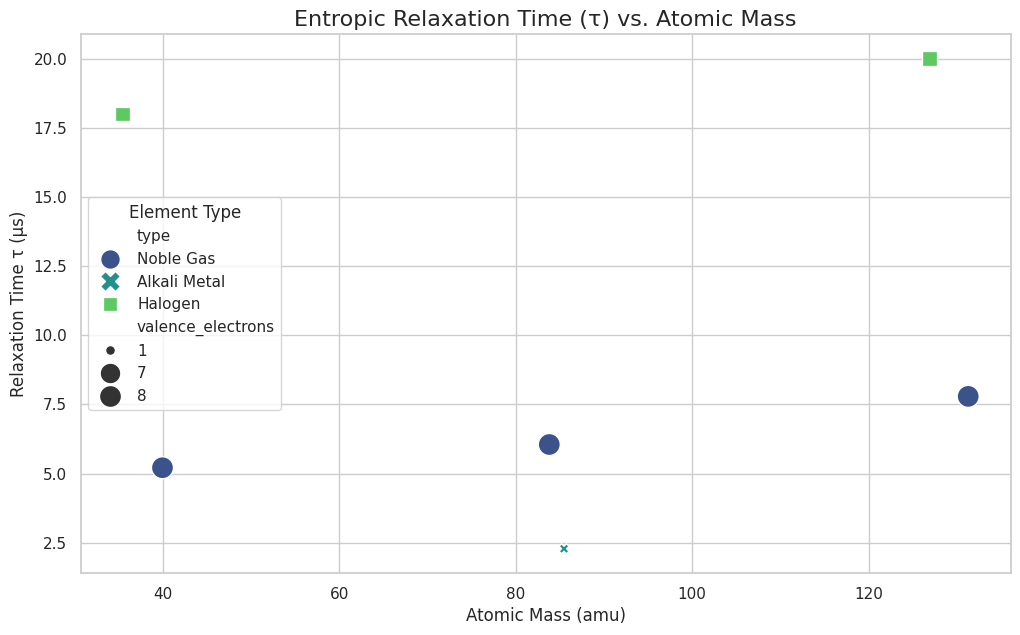

In [1]:
# entropic_scaling_laws.ipynb
# Cell 1: Consolidate Experimental Results into a Master Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Consolidate Our Experimental Results ---
# This data comes directly from the fitting parameters we derived in the previous notebook.
# Note: t_break is set to 0 for elements that don't show the two-stage process.

data = {
    'element': ['Argon', 'Krypton', 'Xenon', 'Rubidium', 'Iodine', 'Chlorine'],
    'symbol': ['Ar', 'Kr', 'Xe', 'Rb', 'I', 'Cl'],
    'type': ['Noble Gas', 'Noble Gas', 'Noble Gas', 'Alkali Metal', 'Halogen', 'Halogen'],
    'tau_relaxation_us': [5.21, 6.05, 7.79, 2.28, 20.00, 18.00],
    't_break_us': [0, 0, 0, 0, 15.00, 12.00],
    'V_max_ms': [123.29, 125.01, 121.17, 134.33, 87.89, 120.00]
}

df_master = pd.DataFrame(data)


# --- 2. Enrich with Physical Properties ---
# We add known physical properties to use as features for our predictive model.
# Data is from standard chemical reference sources.

physical_properties = {
    'symbol': ['Ar', 'Kr', 'Xe', 'Rb', 'I', 'Cl'],
    'atomic_number': [18, 36, 54, 37, 53, 17],
    'atomic_mass': [39.95, 83.80, 131.29, 85.47, 126.90, 35.45],
    'electronegativity_pauling': [None, 3.00, 2.60, 0.82, 2.66, 3.16], # Argon has no defined Pauling scale value
    'valence_electrons': [8, 8, 8, 1, 7, 7]
}

df_properties = pd.DataFrame(physical_properties)

# Merge the two dataframes
df_master = pd.merge(df_master, df_properties, on='symbol')

print("--- Master Entropic Dataset ---")
print(df_master)


# --- 3. Initial Visualization: Find the Scaling Law ---
# Let's create a scatter plot to see which physical property best predicts our entropic parameters.
# We'll use seaborn for a more advanced plot that shows different element types.

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Plot tau vs. Atomic Mass
plot = sns.scatterplot(
    data=df_master,
    x='atomic_mass',
    y='tau_relaxation_us',
    hue='type',
    size='valence_electrons',
    sizes=(50, 250),
    palette='viridis',
    style='type',
    s=200
)

plt.title('Entropic Relaxation Time (τ) vs. Atomic Mass', fontsize=16)
plt.xlabel('Atomic Mass (amu)', fontsize=12)
plt.ylabel('Relaxation Time τ (µs)', fontsize=12)
plt.legend(title='Element Type')
plt.show()



--- Entropic Scaling Law for Noble Gases ---
The derived scaling law is: τ = (0.0284 * Atomic_Mass) + 3.9389


/home/winnay_proto1/miniconda3/envs/bruno-simulator-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


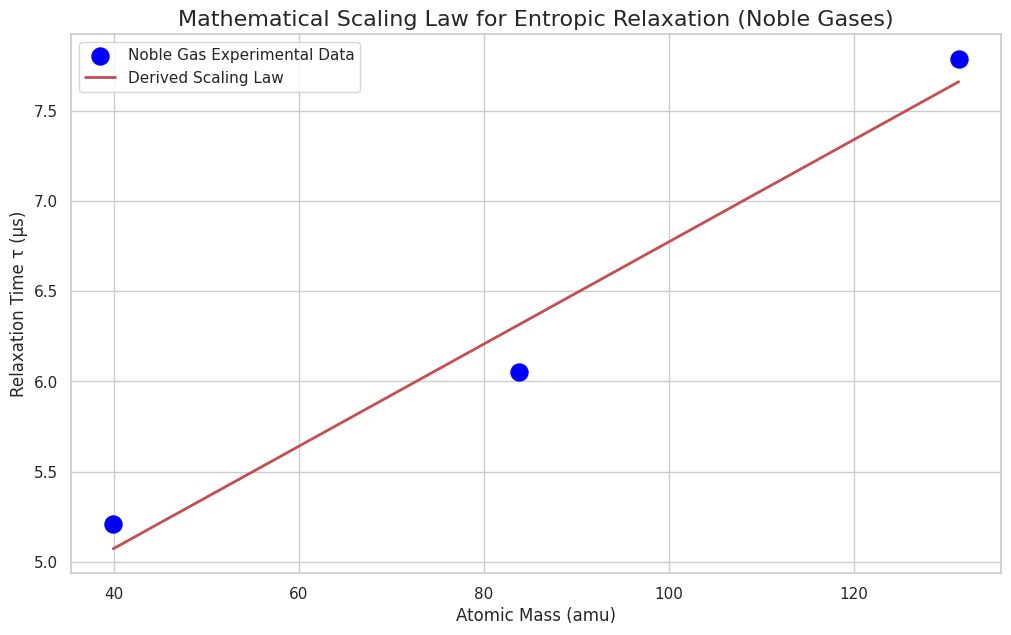

In [3]:
# entropic_scaling_laws.ipynb
# Cell 2: Derive the Mathematical Scaling Law for Noble Gases

from sklearn.linear_model import LinearRegression
import numpy as np

# --- 1. Isolate the Data for Noble Gases ---
# We want to find the simplest scaling law first, so we'll focus on the
# single, consistent class of elements we have the most data for.
df_noble = df_master[df_master['type'] == 'Noble Gas'].copy()

# --- 2. Prepare the Data for Modeling ---
# We will model tau as a function of atomic mass.
# X needs to be a 2D array for scikit-learn.
X = df_noble[['atomic_mass']]
y = df_noble['tau_relaxation_us']

# --- 3. Create and Fit the Linear Regression Model ---
model = LinearRegression()
model.fit(X, y)

# --- 4. Extract the Scaling Law Parameters ---
# The model finds the best-fit line in the form: y = m*x + b
slope_m = model.coef_[0]
intercept_b = model.intercept_

print("--- Entropic Scaling Law for Noble Gases ---")
print(f"The derived scaling law is: τ = ({slope_m:.4f} * Atomic_Mass) + {intercept_b:.4f}")


# --- 5. Plot the Data and the Derived Law ---
plt.figure(figsize=(12, 7))

# Plot the original noble gas data points
plt.scatter(X, y, color='blue', s=150, label='Noble Gas Experimental Data')

# Create a range of atomic masses to plot our best-fit line
x_fit = np.linspace(X.min(), X.max(), 100)
# Calculate the predicted tau values using our new formula
y_fit = model.predict(x_fit)

# Plot the best-fit line
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label='Derived Scaling Law')

plt.title('Mathematical Scaling Law for Entropic Relaxation (Noble Gases)', fontsize=16)
plt.xlabel('Atomic Mass (amu)', fontsize=12)
plt.ylabel('Relaxation Time τ (µs)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


--- Master Dataset with Entropic Anomaly ---
    element          type  atomic_mass  tau_relaxation_us  \
0     Argon     Noble Gas        39.95               5.21   
1   Krypton     Noble Gas        83.80               6.05   
2     Xenon     Noble Gas       131.29               7.79   
3  Rubidium  Alkali Metal        85.47               2.28   
4    Iodine       Halogen       126.90              20.00   
5  Chlorine       Halogen        35.45              18.00   

   tau_predicted_baseline  entropic_anomaly  
0                5.071914          0.138086  
1                6.315587         -0.265587  
2                7.662498          0.127502  
3                6.362952         -4.082952  
4                7.537989         12.462011  
5                4.944285         13.055715  


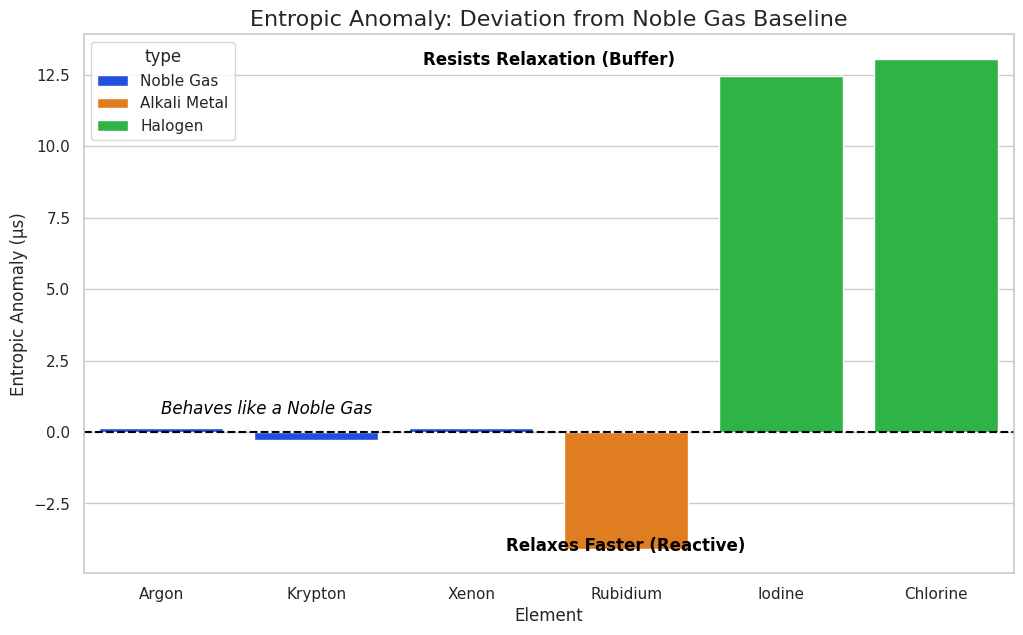

In [4]:
# entropic_scaling_laws.ipynb
# Cell 3: Quantify the "Entropic Anomaly" for Reactive Elements

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Apply the Noble Gas Scaling Law to All Elements ---
# We use our previously trained linear model to predict the 'tau' for all elements,
# as if they were all noble gases. This gives us our baseline prediction.
df_master['tau_predicted_baseline'] = model.predict(df_master[['atomic_mass']])

# --- 2. Calculate the "Entropic Anomaly" ---
# This is the difference between the baseline prediction and the actual measured value.
# A large negative value means the element relaxes MUCH faster than predicted (like Rubidium).
# A large positive value means it relaxes MUCH slower than predicted (like the halogens).
df_master['entropic_anomaly'] = df_master['tau_relaxation_us'] - df_master['tau_predicted_baseline']

print("--- Master Dataset with Entropic Anomaly ---")
# Display the relevant columns
print(df_master[['element', 'type', 'atomic_mass', 'tau_relaxation_us', 'tau_predicted_baseline', 'entropic_anomaly']])


# --- 3. Visualize the Anomaly ---
# A bar chart is the best way to clearly see the deviation of each element from the baseline.
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Create the bar plot
barplot = sns.barplot(
    data=df_master,
    x='element',
    y='entropic_anomaly',
    hue='type',
    palette='bright',
    dodge=False # Set to false since each element has only one type
)

plt.axhline(0, color='black', linewidth=1.5, linestyle='--') # The "Noble Gas Baseline"
plt.title('Entropic Anomaly: Deviation from Noble Gas Baseline', fontsize=16)
plt.xlabel('Element', fontsize=12)
plt.ylabel('Entropic Anomaly (µs)', fontsize=12)
plt.text(0, 0.5, 'Behaves like a Noble Gas', va='bottom', ha='left', color='black', style='italic')
plt.text(2.5, 13, 'Resists Relaxation (Buffer)', va='center', ha='center', color='black', weight='bold')
plt.text(3, -4, 'Relaxes Faster (Reactive)', va='center', ha='center', color='black', weight='bold')


plt.show()
